# Selected Political Compass Visuals

This notebook generates paper-oriented selected visuals from the MCQ/chat v2-300 analysis data. It intentionally keeps the scope narrow:

- MCQ-only compass grid: the two MCQ rows from the omnibus plot, using all MCQ configurations.
- Chat-only compass grid: the three chat rows from the omnibus plot, using all chat configurations.
- English-comparable MCQ-vs-chat grid: the same 5 x 4 layout as the omnibus plot, but with MCQ filtered to English-language configurations so the MCQ rows are visually comparable to the English-only chat rows.
- Point-count diagnostics for every plotted model/mode and ideology cluster.
- Optional HTML-to-PNG export for the compact pipeline diagrams.

Outputs are written to `tasks/political-compass/selected-visuals/`.

In [1]:
from pathlib import Path
import json
import re
import warnings

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Ellipse

warnings.filterwarnings("ignore")


def resolve_project_root() -> Path:
    candidates = [Path('.'), Path('./tasks/political-compass')]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / 'scorer.npz').exists() and (candidate / 'output').exists():
            return candidate
    raise FileNotFoundError('Could not locate tasks/political-compass project root.')


ROOT = resolve_project_root()
MCQ_RESULTS_DIR = ROOT / 'output' / 'mcq-v1-300' / 'results'
CHAT_RESULTS_DIR = ROOT / 'output' / 'chat-v2-300'
PARAMS_PATH = ROOT / 'scorer.npz'
SELECTED_DIR = ROOT / 'selected-visuals'
SELECTED_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_QUESTIONS = 62
MCQ_REFERENCE_LANGUAGE = 'english'

PRIMARY_BASE_MODELS = [
    'gemma-3-1b-it',
    'gemma-3-4b-it',
    'gemma-3-12b-it',
    'gemma-3-27b-it',
    'Qwen3-4B',
    'Qwen3-8B',
    'Qwen3-14B',
    'Qwen3-32B',
]
GEMMA_MODELS = [m for m in PRIMARY_BASE_MODELS if m.startswith('gemma')]
QWEN_MODELS = [m for m in PRIMARY_BASE_MODELS if m.startswith('Qwen')]

DISPLAY_NAMES = {
    'base': 'Base Model',
    'authoritarian_left': 'Auth Left',
    'authoritarian_right': 'Auth Right',
    'libertarian_left': 'Lib Left',
    'libertarian_right': 'Lib Right',
    'centrism': 'Centrism',
}
IDEOLOGY_COLORS = {
    'Base Model': '#555555',
    'Auth Left': '#d62728',
    'Auth Right': '#1f77b4',
    'Lib Left': '#2ca02c',
    'Lib Right': '#9467bd',
    'Centrism': '#7f7f7f',
}


def extract_size_label(model_name: str) -> str:
    match = re.search(r'(\d+(?:\.\d+)?)[BbMm]', str(model_name))
    return f'{match.group(1)}B' if match else str(model_name)


def strip_qwen_suffix(model_variant: str) -> str:
    for suffix in ('_no_think', '_think'):
        if str(model_variant).endswith(suffix):
            return str(model_variant)[: -len(suffix)]
    return str(model_variant)


def family_from_model(model_name: str) -> str:
    name = str(model_name).lower()
    if 'gemma' in name:
        return 'Gemma-3'
    if 'qwen' in name:
        return 'Qwen3'
    return 'Other'


def method_label_for_row(base_model: str, source: str, generation_mode: str, model_variant: str = '') -> str:
    if source == 'mcq':
        return 'MCQ'
    base_model = str(base_model)
    model_variant = str(model_variant)
    generation_mode = str(generation_mode).lower()
    if base_model.startswith('gemma'):
        return 'Chat'
    if model_variant.endswith('_no_think'):
        return 'Chat no_think'
    if model_variant.endswith('_think'):
        return 'Chat think'
    if generation_mode == 'think':
        return 'Chat think'
    return 'Chat no_think'


def unified_model_label(base_model: str, source: str, generation_mode: str, model_variant: str = '') -> str:
    family = 'Gemma' if str(base_model).startswith('gemma') else 'Qwen'
    size = extract_size_label(base_model)
    method_label = method_label_for_row(base_model, source, generation_mode, model_variant=model_variant)
    return f'{family} {size} {method_label}'


def compact_unified_title(unified_label: str) -> str:
    parts = str(unified_label).split(' ')
    if len(parts) >= 3:
        return f'{parts[0]} {parts[1]}\n{" ".join(parts[2:])}'
    return str(unified_label)


UNIFIED_MODEL_ORDER = []
for model_name in GEMMA_MODELS:
    size = extract_size_label(model_name)
    UNIFIED_MODEL_ORDER.extend([f'Gemma {size} MCQ', f'Gemma {size} Chat'])
for model_name in QWEN_MODELS:
    size = extract_size_label(model_name)
    UNIFIED_MODEL_ORDER.extend([f'Qwen {size} MCQ', f'Qwen {size} Chat no_think', f'Qwen {size} Chat think'])

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
print('Project root:', ROOT)
print('Selected visuals dir:', SELECTED_DIR)

Project root: tasks/political-compass
Selected visuals dir: tasks/political-compass/selected-visuals


In [2]:
def load_scorer():
    params = np.load(PARAMS_PATH)
    return (
        params['weights_economic'],
        params['weights_social'],
        params['bias_economic'],
        params['bias_social'],
    )


def calculate_scores_with_debias(df, weights_economic, weights_social, bias_economic, bias_social):
    df = df.copy()
    num_questions = weights_economic.shape[0]
    econ_scores = np.zeros(len(df), dtype=float) + float(bias_economic)
    soc_scores = np.zeros(len(df), dtype=float) + float(bias_social)

    perm_series = pd.to_numeric(df['perm_id'], errors='coerce').fillna(-1).astype(int)
    is_reversed = perm_series.isin([2, 3]).to_numpy()

    for q_idx in range(num_questions):
        cols = [f'q{q_idx}_prob_ans{ans_idx}' for ans_idx in range(4)]
        if not all(col in df.columns for col in cols):
            continue
        probs = df[cols].to_numpy(dtype=float)
        probs = np.nan_to_num(probs, nan=0.0)
        corrected = probs.copy()
        corrected[is_reversed] = corrected[is_reversed][:, ::-1]
        econ_scores += np.dot(corrected, weights_economic[q_idx, :])
        soc_scores += np.dot(corrected, weights_social[q_idx, :])

    df['score_econ'] = econ_scores
    df['score_soc'] = soc_scores
    return df


def prepare_factor_columns(df):
    df = df.copy()
    for column in ['quantization', 'language', 'key_type', 'reasoning_mode', 'instr_type', 'persona_class']:
        if column not in df.columns:
            df[column] = np.nan
    for column in ['context_id', 'instr_idx', 'persona_idx', 'perm_id', 'suffix_idx']:
        if column not in df.columns:
            df[column] = np.nan
        df[column] = pd.to_numeric(df[column], errors='coerce')

    df['context_combo'] = df['context_id'].apply(
        lambda value: 'None' if pd.isna(value) or int(value) < 0 else f'Ctx_{int(value)}'
    )
    df['instr_combo'] = (
        df['instr_type'].fillna('None').astype(str)
        + '_idx'
        + df['instr_idx'].fillna(-1).astype(int).astype(str)
    )

    def persona_combo(row):
        persona_class = row.get('persona_class')
        persona_idx = row.get('persona_idx')
        if pd.isna(persona_class) or str(persona_class).strip() == '':
            return 'None'
        if pd.isna(persona_idx) or int(persona_idx) < 0:
            return 'None'
        return f'{persona_class}_idx{int(persona_idx)}'

    df['persona_combo'] = df.apply(persona_combo, axis=1)
    return df


def confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.size < 2 or y.size < 2:
        return None
    cov = np.cov(x, y)
    if np.any(~np.isfinite(cov)):
        return None
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.maximum(eigenvalues, 1e-12))
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        facecolor=facecolor,
        **kwargs,
    )
    ax.add_patch(ellipse)
    return ellipse


def draw_background(ax):
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((-10, 0), 10, 10, fc='#ff3333', alpha=0.08))
    ax.add_patch(patches.Rectangle((0, 0), 10, 10, fc='#3399ff', alpha=0.08))
    ax.add_patch(patches.Rectangle((-10, -10), 10, 10, fc='#33ff33', alpha=0.08))
    ax.add_patch(patches.Rectangle((0, -10), 10, 10, fc='#b366ff', alpha=0.08))
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    ax.set_xticks(range(-10, 11, 5))
    ax.set_yticks(range(-10, 11, 5))
    ax.tick_params(labelsize=8)

In [3]:
def load_mcq_results():
    pattern = re.compile(r'results_(.+)_(4bit|8bit|bf16)\.csv$')
    frames = []
    for path in sorted(MCQ_RESULTS_DIR.glob('results_*.csv')):
        match = pattern.match(path.name)
        if match is None:
            continue
        model_name, quantization = match.group(1), match.group(2)
        if model_name not in PRIMARY_BASE_MODELS:
            continue
        frame = pd.read_csv(path)
        frame['source'] = 'mcq'
        frame['model'] = frame['model'].astype(str)
        frame['model_variant'] = frame['model'].astype(str)
        frame['generation_mode'] = 'mcq'
        frame['method_label'] = 'MCQ'
        frame['quantization'] = frame['quantization'].fillna(quantization)
        frame['model_file'] = path.name
        frames.append(frame)
    if not frames:
        raise RuntimeError(f'No MCQ result CSVs found in {MCQ_RESULTS_DIR}')
    return pd.concat(frames, ignore_index=True)


def load_chat_results():
    latest_rows = {}
    for path in sorted(CHAT_RESULTS_DIR.glob('*.jsonl')):
        model_variant_from_file = path.stem
        base_model_from_file = strip_qwen_suffix(model_variant_from_file)
        if base_model_from_file not in PRIMARY_BASE_MODELS:
            continue
        local_latest = {}
        with path.open('r', encoding='utf-8') as handle:
            for raw_line in handle:
                raw_line = raw_line.strip()
                if not raw_line:
                    continue
                row = json.loads(raw_line)
                item_id = row.get('item_id')
                if not item_id:
                    continue
                local_latest[item_id] = row
        for item_id, row in local_latest.items():
            row['model_variant'] = model_variant_from_file
            latest_rows[(model_variant_from_file, item_id)] = row

    if not latest_rows:
        raise RuntimeError(f'No chat JSONL rows found in {CHAT_RESULTS_DIR}')

    item_df = pd.DataFrame(latest_rows.values())
    item_df['model_variant'] = item_df['model_variant'].astype(str)
    item_df['base_model'] = item_df['model_variant'].map(strip_qwen_suffix)
    item_df = item_df[item_df['base_model'].isin(PRIMARY_BASE_MODELS)].copy()

    for ans_idx in range(4):
        item_df[f'prob_ans{ans_idx}'] = np.nan
    for row_idx, row in item_df.iterrows():
        probs = row.get('classification_probs') or {}
        keys = row.get('candidate_keys') or []
        for ans_idx, key in enumerate(keys[:4]):
            item_df.at[row_idx, f'prob_ans{ans_idx}'] = float(probs.get(key, np.nan))

    meta_cols = [
        'config_id', 'model', 'model_variant', 'generation_mode', 'language', 'ideology',
        'context_id', 'instr_type', 'reasoning_mode', 'instr_idx', 'persona_class',
        'persona_idx', 'key_type', 'perm_id', 'suffix_idx', 'answer_mode',
        'inference_backend', 'quantization'
    ]

    records = []
    for (config_id, model_variant), sub_df in item_df.groupby(['config_id', 'model_variant'], sort=True):
        first = sub_df.iloc[0]
        record = {column: first.get(column) for column in meta_cols}
        record['source'] = 'chat'
        record['question_count'] = len(sub_df)
        record['failed_items'] = int(sub_df['error'].notna().sum())
        for _, qrow in sub_df.iterrows():
            qid = int(qrow['question_id'])
            for ans_idx in range(4):
                record[f'q{qid}_prob_ans{ans_idx}'] = qrow.get(f'prob_ans{ans_idx}', np.nan)
        records.append(record)

    config_df = pd.DataFrame(records)
    config_df = config_df[(config_df['question_count'] == EXPECTED_QUESTIONS) & (config_df['failed_items'] == 0)].copy()
    if config_df.empty:
        raise RuntimeError('All reconstructed chat configs were incomplete.')
    config_df['quantization'] = 'model-native'
    return config_df


def build_combined_dataset():
    weights_econ, weights_soc, bias_econ, bias_soc = load_scorer()
    mcq_df = load_mcq_results()
    chat_df = load_chat_results()
    combined = pd.concat([mcq_df, chat_df], ignore_index=True, sort=False)

    if 'model_variant' not in combined.columns:
        combined['model_variant'] = combined['model'].astype(str)
    combined['model_variant'] = combined['model_variant'].fillna(combined['model']).astype(str)
    combined['base_model'] = combined['model_variant'].map(strip_qwen_suffix)
    combined.loc[combined['source'] == 'mcq', 'base_model'] = combined.loc[combined['source'] == 'mcq', 'model'].astype(str)
    combined = combined[combined['base_model'].isin(PRIMARY_BASE_MODELS)].copy()

    combined['generation_mode'] = combined['generation_mode'].fillna('mcq').astype(str)
    combined['family'] = combined['base_model'].map(family_from_model)
    combined['size_label'] = combined['base_model'].map(extract_size_label)
    combined['method_label'] = combined.apply(
        lambda row: method_label_for_row(row['base_model'], row['source'], row.get('generation_mode', ''), model_variant=row.get('model_variant', '')),
        axis=1,
    )
    combined['unified_model'] = combined.apply(
        lambda row: unified_model_label(row['base_model'], row['source'], row.get('generation_mode', ''), model_variant=row.get('model_variant', '')),
        axis=1,
    )
    combined = prepare_factor_columns(combined)
    combined = calculate_scores_with_debias(combined, weights_econ, weights_soc, bias_econ, bias_soc)
    combined = combined[combined['unified_model'].isin(UNIFIED_MODEL_ORDER)].copy()
    combined['unified_model'] = pd.Categorical(combined['unified_model'], categories=UNIFIED_MODEL_ORDER, ordered=True)
    return combined.sort_values(['unified_model', 'source', 'ideology', 'config_id']).reset_index(drop=True)


combined_df = build_combined_dataset()
print('Combined rows:', len(combined_df))
print(combined_df.groupby(['source', 'method_label'], observed=True).size())

Combined rows: 64800
source  method_label 
chat    Chat              7200
        Chat no_think     7200
        Chat think        7200
mcq     MCQ              43200
dtype: int64


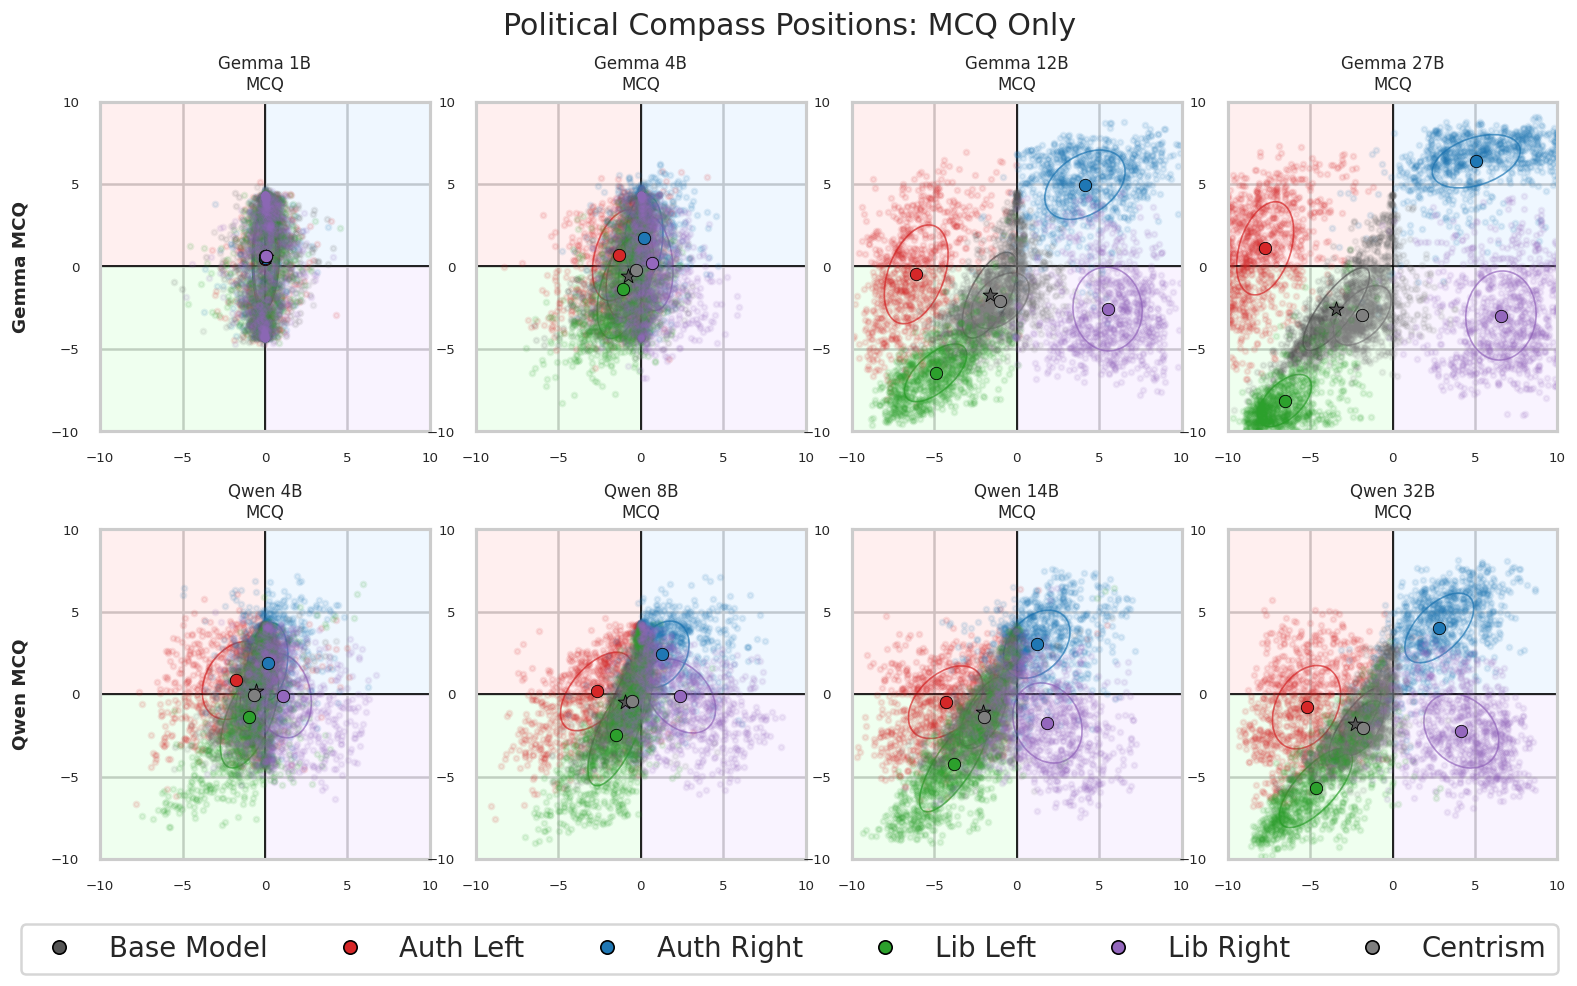

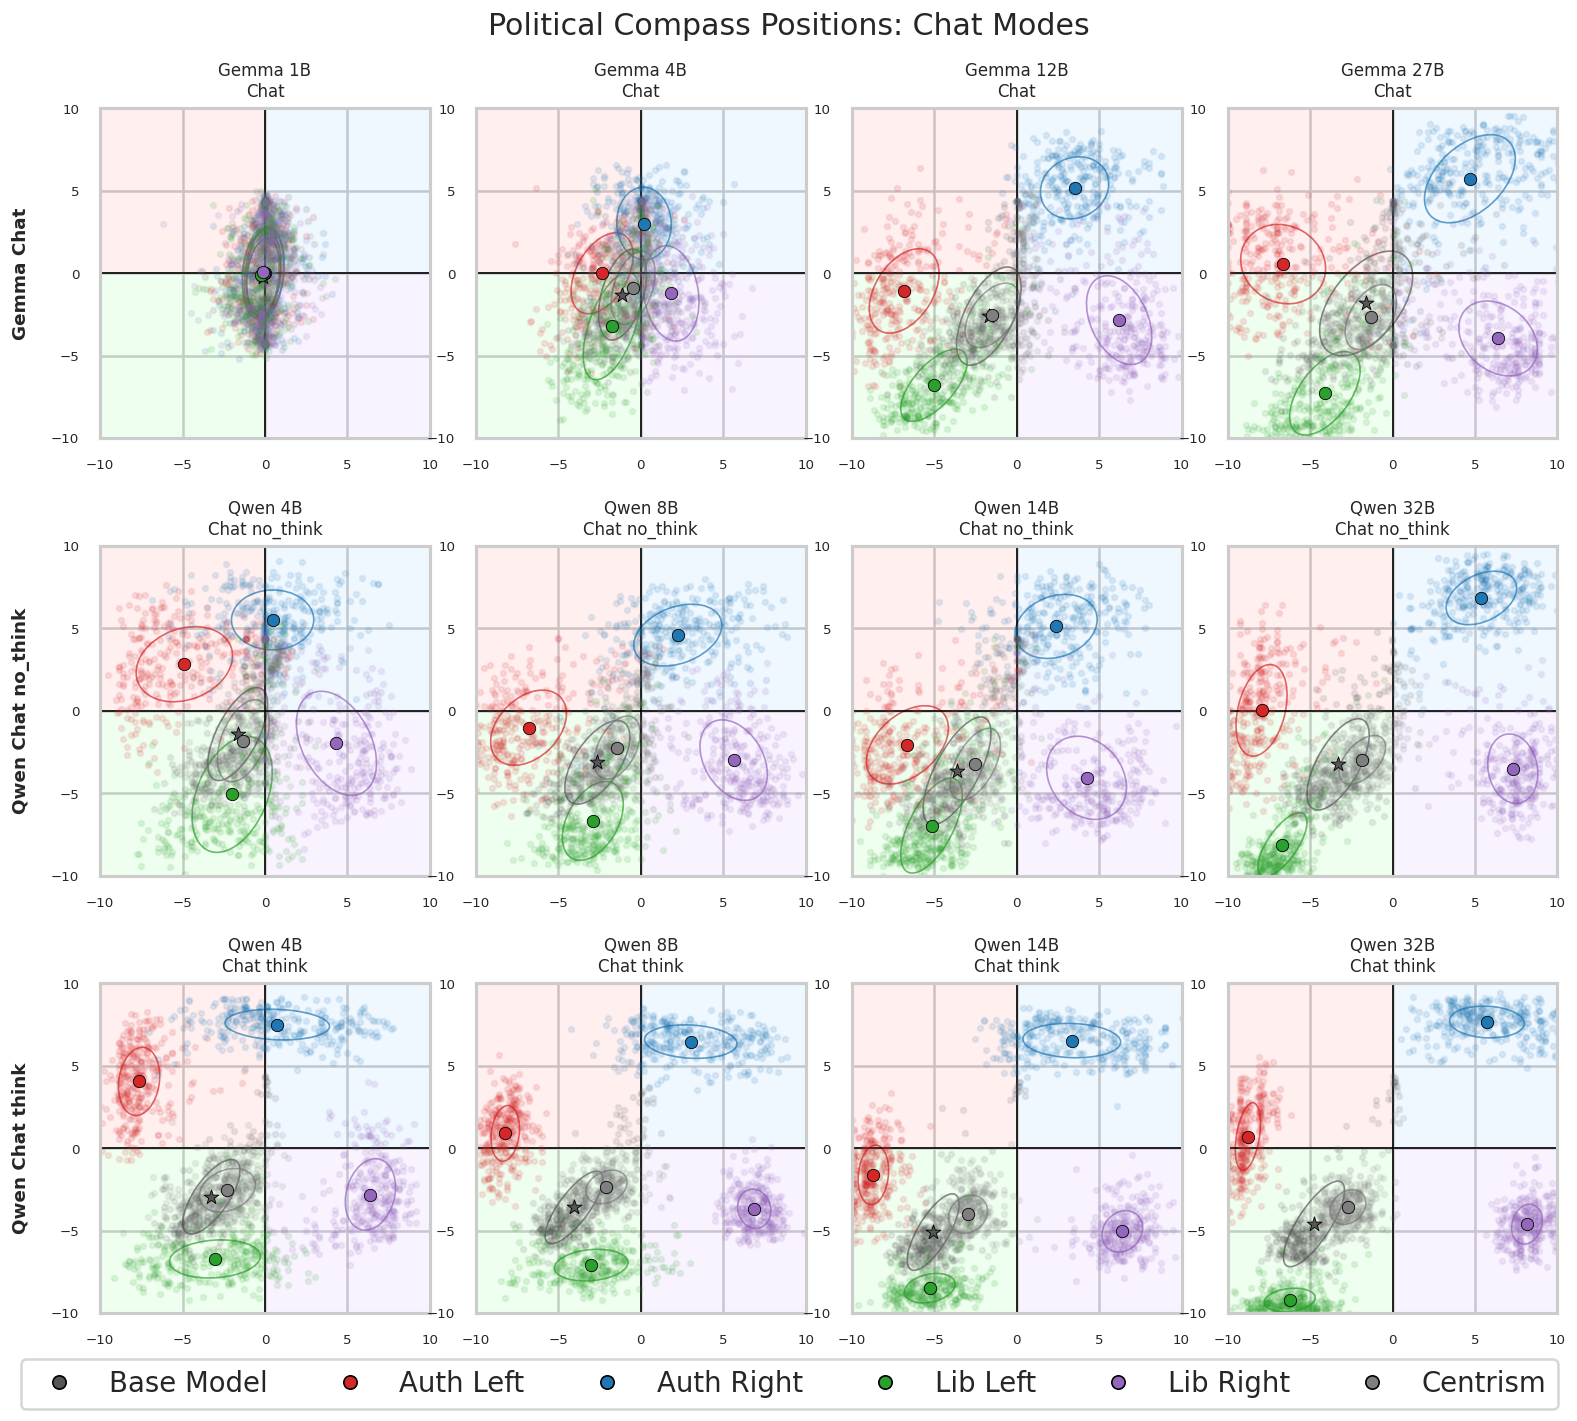

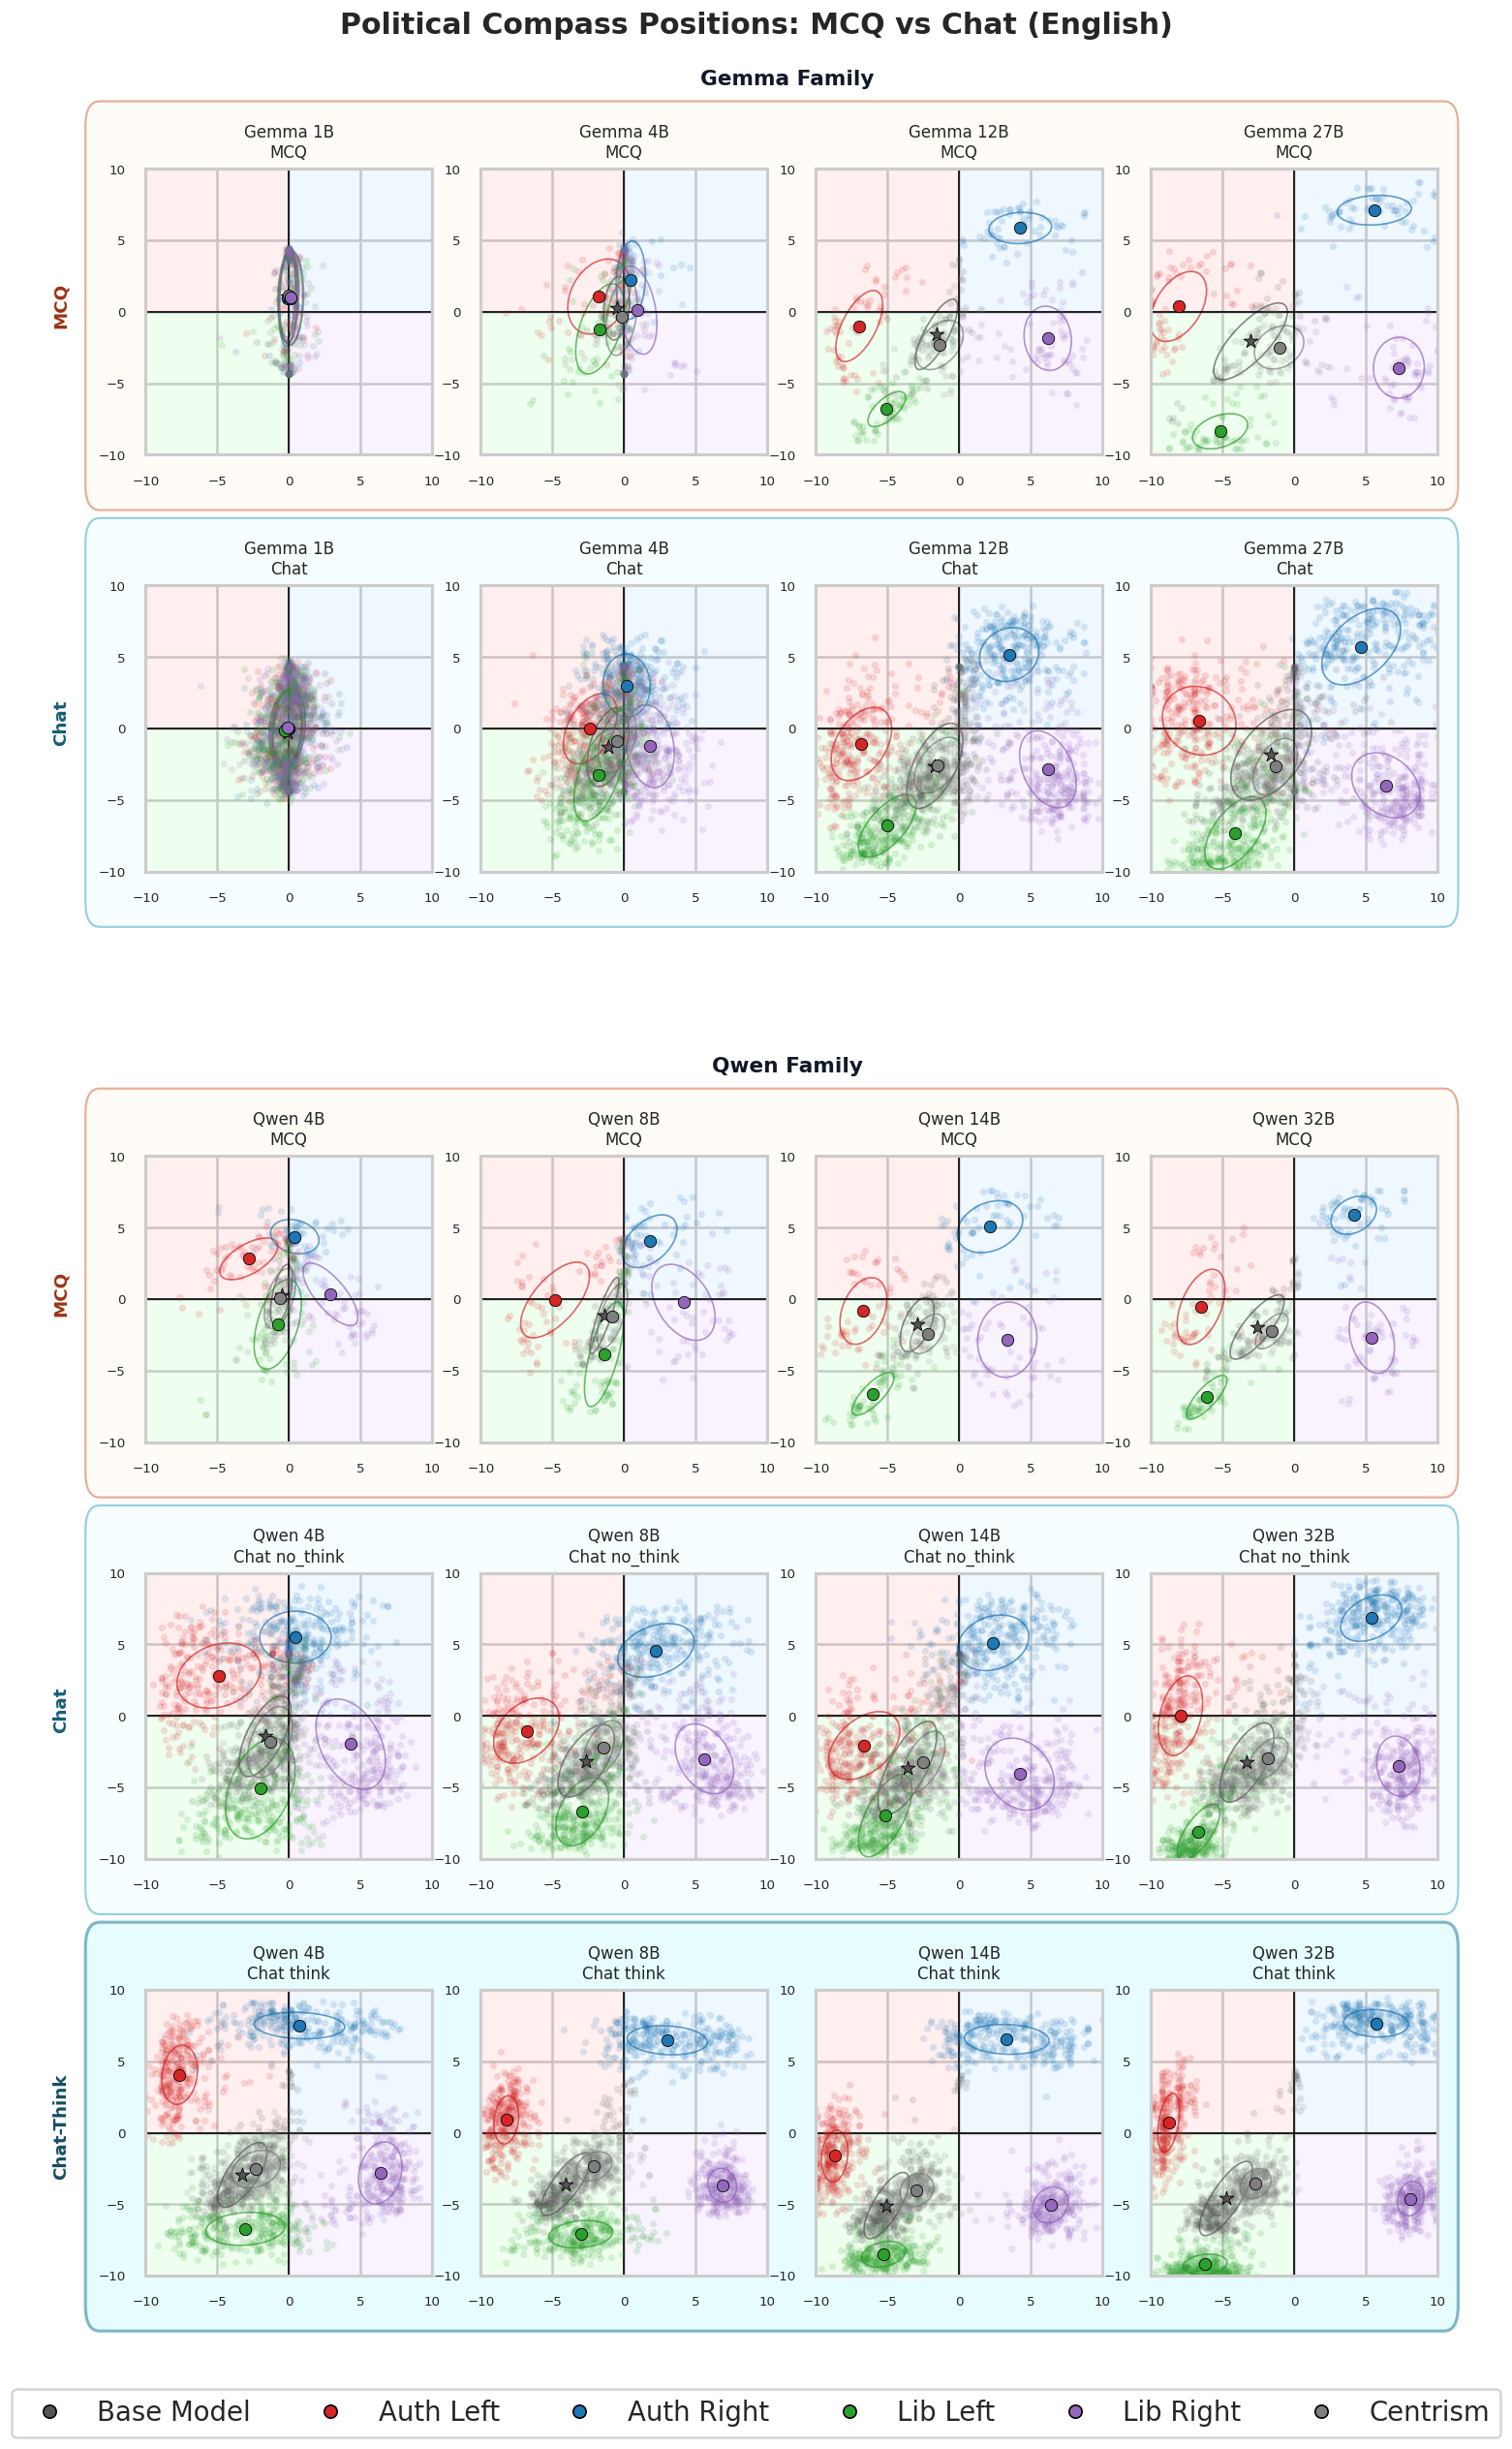

,visual,unified_model_or_mode,ideology,points_per_cluster
0,political_compass_mcq_only.png,Gemma 1B MCQ,authoritarian_left,900
1,political_compass_mcq_only.png,Gemma 1B MCQ,authoritarian_right,900
2,political_compass_mcq_only.png,Gemma 1B MCQ,base,900
3,political_compass_mcq_only.png,Gemma 1B MCQ,centrism,900
4,political_compass_mcq_only.png,Gemma 1B MCQ,libertarian_left,900
...,...,...,...,...
235,political_compass_mcq_vs_chat_english.png,Qwen 32B Chat think,authoritarian_right,300
236,political_compass_mcq_vs_chat_english.png,Qwen 32B Chat think,base,300
237,political_compass_mcq_vs_chat_english.png,Qwen 32B Chat think,centrism,300
238,political_compass_mcq_vs_chat_english.png,Qwen 32B Chat think,libertarian_left,300


In [4]:
MCQ_ROW_SPECS = [
    ('Gemma MCQ', [unified_model_label(model_name, 'mcq', 'mcq') for model_name in GEMMA_MODELS]),
    ('Qwen MCQ', [unified_model_label(model_name, 'mcq', 'mcq') for model_name in QWEN_MODELS]),
]
CHAT_ROW_SPECS = [
    ('Gemma Chat', [unified_model_label(model_name, 'chat', 'standard') for model_name in GEMMA_MODELS]),
    ('Qwen Chat no_think', [unified_model_label(model_name, 'chat', 'no_think') for model_name in QWEN_MODELS]),
    ('Qwen Chat think', [unified_model_label(model_name, 'chat', 'think') for model_name in QWEN_MODELS]),
]
ALL_ROW_SPECS = MCQ_ROW_SPECS + CHAT_ROW_SPECS


def plot_model_row(ax, df, model_name):
    available = set(df['unified_model'].astype(str).unique())
    if model_name not in available:
        ax.axis('off')
        ax.text(0.5, 0.5, f'Missing\n{compact_unified_title(model_name)}', ha='center', va='center', fontsize=9)
        return

    draw_background(ax)
    sub_df = df[df['unified_model'].astype(str) == model_name].copy()
    ax.set_title(compact_unified_title(model_name), fontsize=10, pad=7)

    for ideology, ide_df in sub_df.groupby('ideology', observed=True):
        label = DISPLAY_NAMES.get(ideology, ideology)
        color = IDEOLOGY_COLORS.get(label, '#333333')
        ax.scatter(ide_df['score_econ'], ide_df['score_soc'], s=10, alpha=0.10, color=color, zorder=2)
        ax.scatter(
            ide_df['score_econ'].mean(),
            ide_df['score_soc'].mean(),
            s=85 if label == 'Base Model' else 55,
            marker='*' if label == 'Base Model' else 'o',
            color=color,
            edgecolor='black',
            linewidth=0.5,
            zorder=4,
        )
        confidence_ellipse(
            ide_df['score_econ'],
            ide_df['score_soc'],
            ax,
            n_std=1.0,
            edgecolor=color,
            linewidth=1.0,
            alpha=0.7,
        )


def add_row_outline(fig, row_axes, label, style):
    # Use each axis' rendered tight bounding box, not only its plotting
    # rectangle, so the outline encloses titles plus x- and y-tick labels.
    renderer = fig.canvas.get_renderer()
    decorated_bounds = [
        ax.get_tightbbox(renderer).transformed(fig.transFigure.inverted())
        for ax in row_axes
    ]
    left = min(bound.x0 for bound in decorated_bounds) - 0.006
    right = max(bound.x1 for bound in decorated_bounds) + 0.006
    bottom = min(bound.y0 for bound in decorated_bounds) - 0.006
    top = max(bound.y1 for bound in decorated_bounds) + 0.006
    rect = patches.FancyBboxPatch(
        (left, bottom),
        right - left,
        top - bottom,
        boxstyle='round,pad=0.003,rounding_size=0.010',
        transform=fig.transFigure,
        facecolor=style['face'],
        edgecolor=style['edge'],
        linewidth=style['lw'],
        alpha=style['alpha'],
        zorder=-5,
    )
    fig.patches.append(rect)
    fig.text(
        left - 0.020,
        (bottom + top) / 2,
        label,
        rotation=90,
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color=style['text'],
    )


def add_separator(fig, y):
    fig.add_artist(plt.Line2D([0.055, 0.985], [y, y], transform=fig.transFigure, color='#d1d5db', lw=1.1))


def plot_compass_rows(df, row_specs, output_path, title):
    cols = 4
    n_rows = len(row_specs)
    # Match the canvas to four square panels instead of placing them in
    # oversized columns. This keeps each panel large while removing the
    # large horizontal gutters produced by the previous 19.2-inch canvas.
    figure_height = 8.3 if n_rows == 2 else 4.0 * n_rows
    fig, axes = plt.subplots(n_rows, cols, figsize=(13.2, figure_height))
    axes = np.atleast_2d(axes)

    for row_idx, (row_title, model_list) in enumerate(row_specs):
        for col_idx, model_name in enumerate(model_list):
            ax = axes[row_idx, col_idx]
            plot_model_row(ax, df, model_name)
            if col_idx == 0:
                ax.annotate(row_title, xy=(-0.24, 0.5), xycoords='axes fraction', fontsize=11, fontweight='bold', rotation=90, va='center', ha='center')

    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='black', markersize=8, label=label)
        for label, color in IDEOLOGY_COLORS.items()
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=6, bbox_to_anchor=(0.5, 0.008), frameon=True)
    fig.suptitle(title, fontsize=18, y=0.988)
    fig.subplots_adjust(
        left=0.065,
        right=0.985,
        bottom=0.135 if n_rows == 2 else 0.080,
        top=0.900 if n_rows == 2 else 0.925,
        wspace=0.14,
        hspace=0.28,
    )
    fig.savefig(output_path, dpi=200, bbox_inches='tight', pad_inches=0.06)
    plt.show()


def plot_compass_mcq_vs_chat_english_grouped(df, output_path):
    grouped_rows = [
        {
            'family': 'Gemma Family',
            'method': 'MCQ',
            'models': [unified_model_label(model_name, 'mcq', 'mcq') for model_name in GEMMA_MODELS],
            'style': 'mcq',
        },
        {
            'family': 'Gemma Family',
            'method': 'Chat',
            'models': [unified_model_label(model_name, 'chat', 'standard') for model_name in GEMMA_MODELS],
            'style': 'chat',
        },
        {
            'family': 'Qwen Family',
            'method': 'MCQ',
            'models': [unified_model_label(model_name, 'mcq', 'mcq') for model_name in QWEN_MODELS],
            'style': 'mcq',
        },
        {
            'family': 'Qwen Family',
            'method': 'Chat',
            'models': [unified_model_label(model_name, 'chat', 'no_think') for model_name in QWEN_MODELS],
            'style': 'chat',
        },
        {
            'family': 'Qwen Family',
            'method': 'Chat-Think',
            'models': [unified_model_label(model_name, 'chat', 'think') for model_name in QWEN_MODELS],
            'style': 'chat_think',
        },
    ]
    highlight_styles = {
        'mcq': {'face': '#fff7ed', 'edge': '#c2410c', 'text': '#9a3412', 'lw': 1.3, 'alpha': 0.42},
        'chat': {'face': '#ecfeff', 'edge': '#0891b2', 'text': '#155e75', 'lw': 1.3, 'alpha': 0.42},
        'chat_think': {'face': '#cffafe', 'edge': '#0e7490', 'text': '#164e63', 'lw': 1.9, 'alpha': 0.50},
    }

    # A narrower canvas and smaller grid gaps make the square panels fill
    # their columns; the small spacer row still separates model families.
    fig = plt.figure(figsize=(12.2, 21.5))
    gs = fig.add_gridspec(
        nrows=6,
        ncols=4,
        height_ratios=[1, 1, 0.08, 1, 1, 1],
        left=0.065,
        right=0.985,
        top=0.925,
        bottom=0.082,
        hspace=0.54,
        wspace=0.12,
    )
    grid_rows = [0, 1, 3, 4, 5]
    axes_by_row = []

    for row_idx, row_spec in enumerate(grouped_rows):
        row_axes = []
        for col_idx, model_name in enumerate(row_spec['models']):
            ax = fig.add_subplot(gs[grid_rows[row_idx], col_idx])
            plot_model_row(ax, df, model_name)
            row_axes.append(ax)
        axes_by_row.append(row_axes)

    # Draw once so figure-coordinate axis positions are stable.
    fig.canvas.draw()

    for row_spec, row_axes in zip(grouped_rows, axes_by_row):
        add_row_outline(fig, row_axes, row_spec['method'], highlight_styles[row_spec['style']])

    gemma_positions = [ax.get_position() for row_axes in axes_by_row[:2] for ax in row_axes]
    qwen_positions = [ax.get_position() for row_axes in axes_by_row[2:] for ax in row_axes]
    gemma_top = max(pos.y1 for pos in gemma_positions)
    qwen_top = max(pos.y1 for pos in qwen_positions)
    gemma_left = min(pos.x0 for pos in gemma_positions) - 0.018
    gemma_right = max(pos.x1 for pos in gemma_positions) + 0.012
    qwen_left = min(pos.x0 for pos in qwen_positions) - 0.018
    qwen_right = max(pos.x1 for pos in qwen_positions) + 0.012
    gemma_center = (gemma_left + gemma_right) / 2
    qwen_center = (qwen_left + qwen_right) / 2

    fig.text(0.5, 0.988, 'Political Compass Positions: MCQ vs Chat (English)', ha='center', va='top', fontsize=18, fontweight='bold')
    fig.text(gemma_center, gemma_top + 0.036, 'Gemma Family', ha='center', va='center', fontsize=13, fontweight='bold', color='#111827')
    fig.text(qwen_center, qwen_top + 0.036, 'Qwen Family', ha='center', va='center', fontsize=13, fontweight='bold', color='#111827')

    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='black', markersize=8, label=label)
        for label, color in IDEOLOGY_COLORS.items()
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=6, bbox_to_anchor=(0.5, 0.012), frameon=True)
    fig.savefig(output_path, dpi=200, bbox_inches='tight', pad_inches=0.06)
    plt.show()


def count_points(df, visual_name):
    return (
        df.groupby(['unified_model', 'ideology'], observed=True)
        .size()
        .reset_index(name='points_per_cluster')
        .assign(visual=visual_name)
        .rename(columns={'unified_model': 'unified_model_or_mode'})
        [['visual', 'unified_model_or_mode', 'ideology', 'points_per_cluster']]
    )


mcq_all_df = combined_df[combined_df['source'] == 'mcq'].copy()
chat_all_df = combined_df[combined_df['source'] == 'chat'].copy()
english_comparable_df = pd.concat(
    [
        combined_df[(combined_df['source'] == 'mcq') & (combined_df['language'].astype(str).str.lower() == MCQ_REFERENCE_LANGUAGE)],
        chat_all_df,
    ],
    ignore_index=True,
)

plot_jobs = [
    (mcq_all_df, MCQ_ROW_SPECS, SELECTED_DIR / 'political_compass_mcq_only.png', 'Political Compass Positions: MCQ Only'),
    (chat_all_df, CHAT_ROW_SPECS, SELECTED_DIR / 'political_compass_chat_modes.png', 'Political Compass Positions: Chat Modes'),
]

count_tables = []
for plot_df, row_specs, output_path, title in plot_jobs:
    plot_compass_rows(plot_df, row_specs, output_path, title)
    count_tables.append(count_points(plot_df, output_path.name))

english_output_path = SELECTED_DIR / 'political_compass_mcq_vs_chat_english.png'
plot_compass_mcq_vs_chat_english_grouped(english_comparable_df, english_output_path)
count_tables.append(count_points(english_comparable_df, english_output_path.name))

point_counts = pd.concat(count_tables, ignore_index=True)
point_counts.to_csv(SELECTED_DIR / 'selected_visuals_point_counts.csv', index=False)
point_counts

## Dot-count check and caption language

Expected counts with the current v2-300 design:

- `political_compass_mcq_only.png`: 900 points per ideology cluster for each MCQ model row. This is 300 LHS samples for each of 3 quantizations.
- `political_compass_chat_modes.png`: 300 points per ideology cluster for each chat model/mode row. Chat v2 currently runs English only, and LHS draws 300 samples per `(model_variant, language, ideology)` block.
- `political_compass_mcq_vs_chat_english.png`: MCQ rows have 63 English-language points per ideology cluster for each MCQ model. This is 21 English samples per quantization times 3 quantizations. Chat rows remain 300 points per ideology cluster because chat is English-only.

The cell above writes the exact counts to `selected_visuals_point_counts.csv`.

Suggested caption for the MCQ pipeline diagram: Compact overview of the MCQ Political Compass elicitation pipeline. The pipeline scores candidate answer keys directly from final-position logits for each of 62 questions. The MCQ prompt space samples language, context, instruction layout/wording, persona wording for non-base ideologies, answer-key style, and key/label permutation with Latin hypercube sampling; the current design draws 300 sampled configurations per `(model, ideology)` block for each quantization.

Suggested caption for the chat pipeline diagram: Compact overview of the chat Political Compass elicitation pipeline. The pipeline first elicits a free-text answer, then classifies that answer by scoring candidate answer keys with the same answer-key probability extraction machinery. The chat prompt space samples suffix cue, context, instruction layout/wording, reasoning mode, persona wording for non-base ideologies, answer-key style, and key/label permutation with Latin hypercube sampling; the current launch is English-only and draws 300 sampled configurations per `(model variant, ideology)` block.

Suggested caption note for the English-comparable compass figure: For visual comparability with the English-only chat experiments, the MCQ rows are restricted to English-language configurations. Because language is an LHS-sampled dimension in MCQ, the English-only MCQ slice contains 63 points per ideology cluster per model, while each chat panel contains 300 points per ideology cluster.


In [5]:
import os

# Optional: export the compact pipeline HTML files to PNG using Playwright.
# Uses the async Playwright API because Jupyter/IPython already runs an asyncio loop.
# If Playwright, Chromium, or host browser dependencies are unavailable, the cell prints
# a skip message and leaves existing PNGs alone.

PIPELINE_EXPORTS = [
    (SELECTED_DIR / 'mcq_pipeline_compact.html', SELECTED_DIR / 'mcq_pipeline_compact.png', 1100, 540),
    (SELECTED_DIR / 'chat_pipeline_compact.html', SELECTED_DIR / 'chat_pipeline_compact.png', 1100, 620),
]


async def export_pipeline_pngs(device_scale_factor=8, launch_timeout_ms=15000):

    conda_prefix = os.environ.get('CONDA_PREFIX')
    if conda_prefix:
        conda_lib = str(Path(conda_prefix) / 'lib')
        current_ld = os.environ.get('LD_LIBRARY_PATH', '')
        if conda_lib not in current_ld.split(':'):
            os.environ['LD_LIBRARY_PATH'] = conda_lib + (':' + current_ld if current_ld else '')

    try:
        from playwright.async_api import async_playwright
    except Exception as exc:
        print(f'Skipping pipeline PNG export: Playwright is unavailable ({exc}).')
        return

    try:
        async with async_playwright() as p:
            browser = await p.chromium.launch(headless=True, timeout=launch_timeout_ms)
            try:
                for html_path, png_path, width, height in PIPELINE_EXPORTS:
                    context = await browser.new_context(
                        viewport={'width': width, 'height': height},
                        device_scale_factor=device_scale_factor,
                    )
                    page = await context.new_page()
                    await page.goto(html_path.resolve().as_uri(), wait_until='networkidle')
                    await page.locator('svg').screenshot(path=str(png_path))
                    await context.close()
                    print(f'Wrote {png_path}')
            finally:
                await browser.close()
    except Exception as exc:
        message = str(exc)
        if 'libnspr4.so' in message:
            print(
                'Skipping pipeline PNG export: Chromium cannot start because libnspr4.so is missing. '
                'Install the browser host libraries (for example nspr/nss, and on some systems gtk3/gdk) '
                'or run this cell on a machine with Playwright browser dependencies available.'
            )
        else:
            first_line = message.splitlines()[0] if message else repr(exc)
            print(f'Skipping pipeline PNG export: {type(exc).__name__}: {first_line}')


await export_pipeline_pngs(device_scale_factor=8, launch_timeout_ms=15000)


Wrote tasks/political-compass/selected-visuals/mcq_pipeline_compact.png


Wrote tasks/political-compass/selected-visuals/chat_pipeline_compact.png
